In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
POINTS = np.arange(10, 501, 5)
fs_vary_all = np.array([])
fs_vary_phys = np.array([])
fs_vary_nuis = np.array([])
chi2_with_grad = np.array([])
chi2_no_grad = np.array([])

for p in POINTS:
    with open(f'./scaling_outputs/scale_exclude_test_{p}pulls.txt', 'r') as f:
        lines = f.readlines()
        for line in lines:
            if 'fillspectra_vary_all' in line:
                line_arr = line.split()[-1].split('=')[-1]
                fs_vary_all = np.append(fs_vary_all, float(line_arr))
            elif 'fillspectra_vary_phys' in line:
                line_arr = line.split()[-1].split('=')[-1]
                fs_vary_phys = np.append(fs_vary_phys, float(line_arr))
            elif 'fillspectra_vary_nuis' in line:
                line_arr = line.split()[-1].split('=')[-1]
                fs_vary_nuis = np.append(fs_vary_nuis, float(line_arr))
            elif 'metric_vary_all' in line:
                line_arr = line.split()[-1].split('=')[-1]
                chi2_no_grad = np.append(chi2_no_grad, float(line_arr))
            elif 'metric_grad_vary_all' in line:
                line_arr = line.split()[-1].split('=')[-1]
                chi2_with_grad = np.append(chi2_with_grad, float(line_arr))
    f.close()

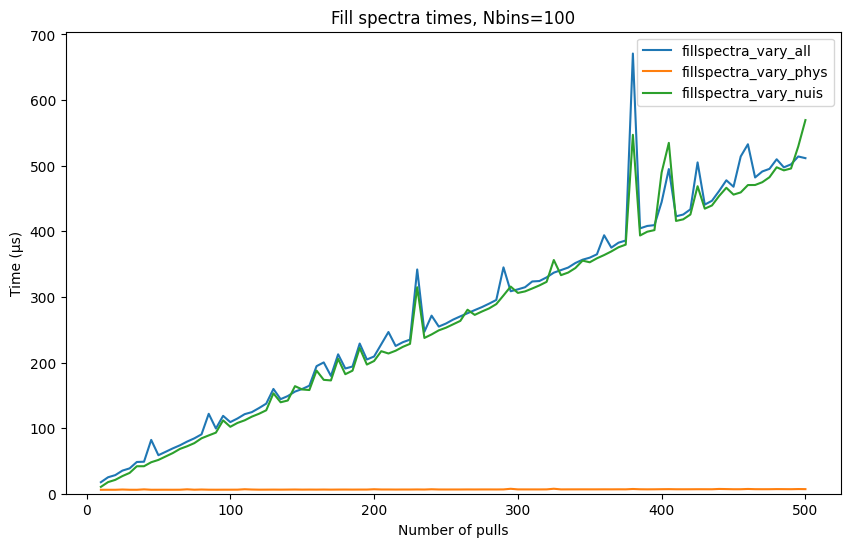

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(POINTS, fs_vary_all, label='fillspectra_vary_all')
plt.plot(POINTS, fs_vary_phys, label='fillspectra_vary_phys')
plt.plot(POINTS, fs_vary_nuis, label='fillspectra_vary_nuis')
plt.legend()
plt.xlabel('Number of pulls')
plt.title('Fill spectra times, Nbins=100')
plt.ylabel('Time (μs)')
plt.ylim(0,)
plt.show()

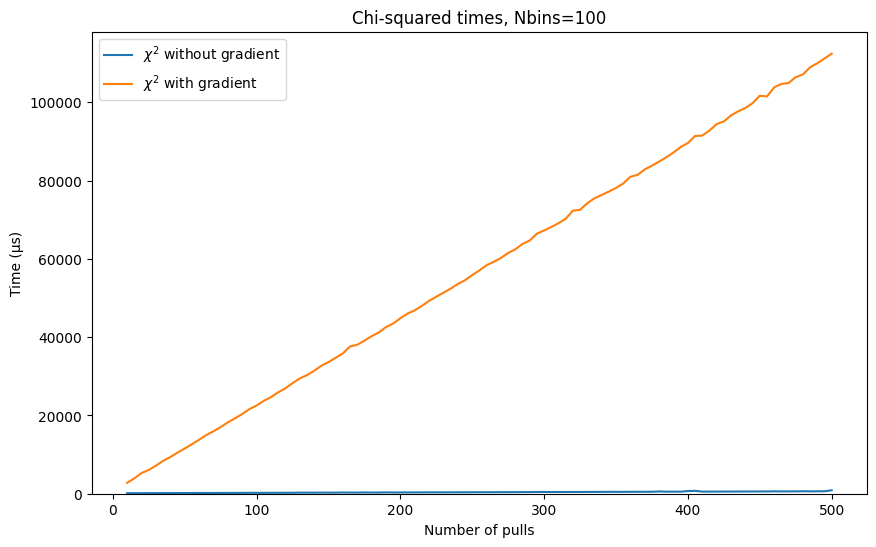

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(POINTS, chi2_no_grad, label='$\\chi^2$ without gradient')
plt.plot(POINTS, chi2_with_grad, label='$\\chi^2$ with gradient')
plt.legend()
plt.xlabel('Number of pulls')
plt.title('Chi-squared times, Nbins=100')
plt.ylabel('Time (μs)')
plt.ylim(0,)
plt.show()